# Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Data

In [30]:
data = pd.read_csv('./data/Titanic-Dataset.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [32]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [33]:
missing = (data.isnull().sum() / len(data)) * 100
missing[missing > 0]

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

# Data Cleaning

## Age

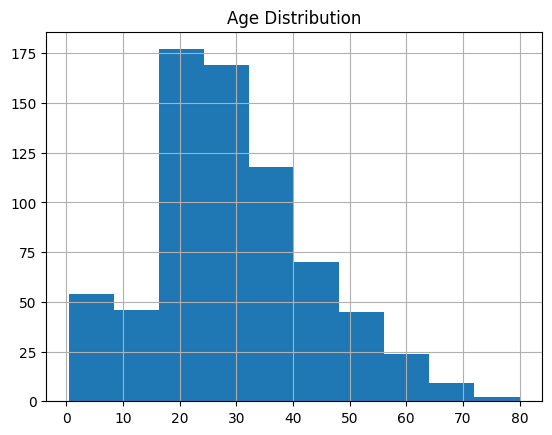

In [34]:
data['Age'].hist()
plt.title('Age Distribution')
plt.show()

In [35]:
data['Age'] = data['Age'].fillna(data['Age'].median())

## Embarked

In [36]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [37]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

## Cabin

In [38]:
data.drop('Cabin', axis=1, inplace=True)

In [39]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Feature Investigation

## Sex vs Survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


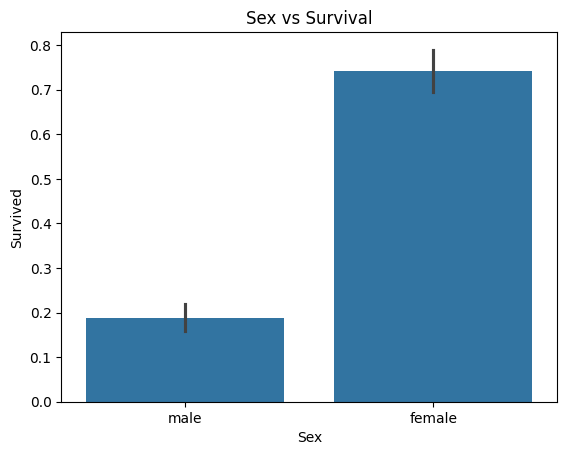

In [40]:
print(data.groupby('Sex')['Survived'].mean())

sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Sex vs Survival')
plt.show()

## Passenger Class vs Survival

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Correlation: -0.3384810359610148


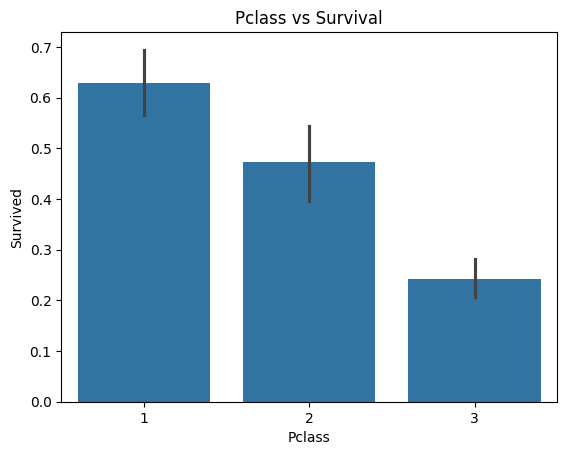

In [41]:
print(data.groupby('Pclass')['Survived'].mean())
print('Correlation:', data['Survived'].corr(data['Pclass']))

sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Pclass vs Survival')
plt.show()

## Age vs Survival

Correlation: -0.06491041993052585


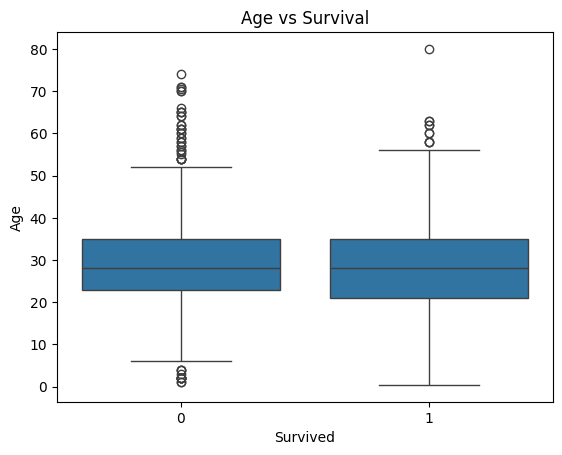

In [42]:
print('Correlation:', data['Survived'].corr(data['Age']))

sns.boxplot(x='Survived', y='Age', data=data)
plt.title('Age vs Survival')
plt.show()

## Fare vs Survival

Correlation: 0.2573065223849622


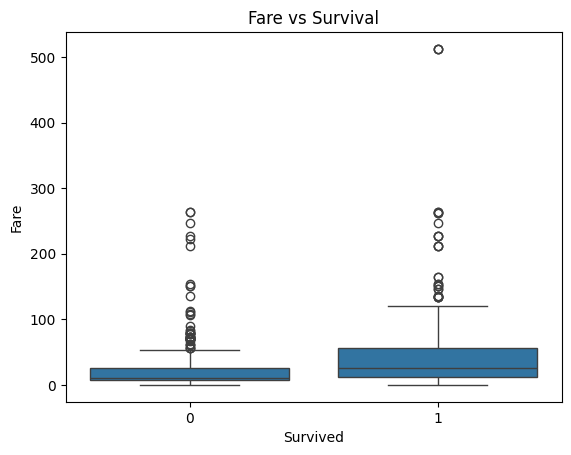

In [43]:
print('Correlation:', data['Survived'].corr(data['Fare']))

sns.boxplot(x='Survived', y='Fare', data=data)
plt.title('Fare vs Survival')
plt.show()

## Embarked vs Survival

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


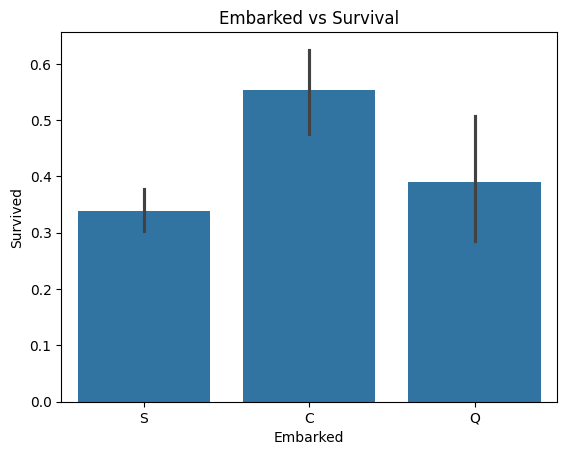

In [44]:
print(data.groupby('Embarked')['Survived'].mean())

sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Embarked vs Survival')
plt.show()

## Family Features

In [45]:
print('SibSp vs Survival')
print(data.groupby('SibSp')['Survived'].mean())

SibSp vs Survival
SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64


In [46]:
print('Parch vs Survival')
print(data.groupby('Parch')['Survived'].mean())

Parch vs Survival
Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


In [47]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

## Correlation Matrix

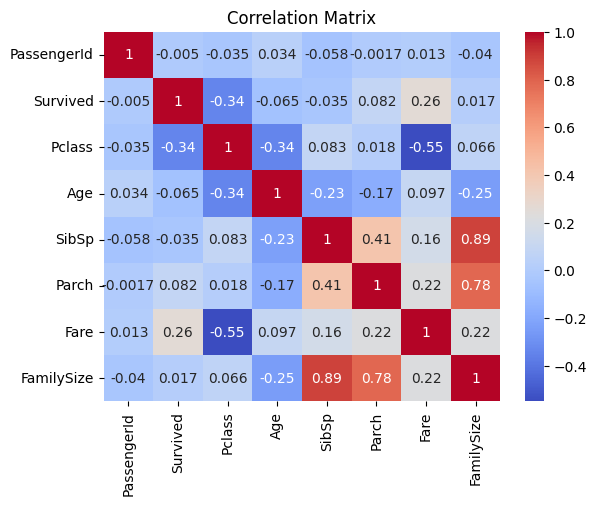

In [48]:
corr_matrix = data.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Feature Engineering

## IsAlone

IsAlone
No     0.505650
Yes    0.303538
Name: Survived, dtype: float64


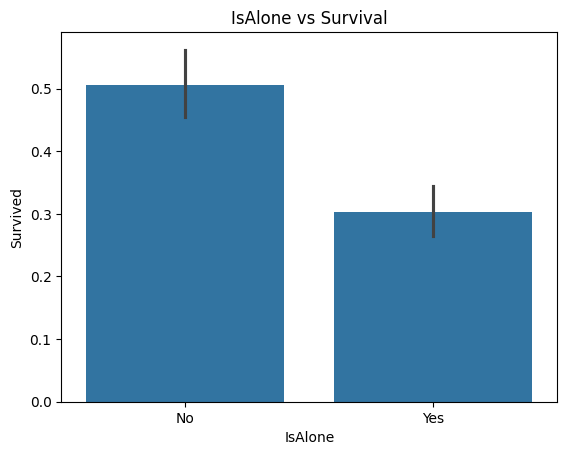

In [49]:
data['IsAlone'] = np.where(data['FamilySize'] == 1, 'Yes', 'No')

print(data.groupby('IsAlone')['Survived'].mean())

sns.barplot(x='IsAlone', y='Survived', data=data)
plt.title('IsAlone vs Survival')
plt.show()

## AgeGroup

AgeGroup
Child     0.579710
Teen      0.410526
Adult     0.365193
Senior    0.269231
Name: Survived, dtype: float64


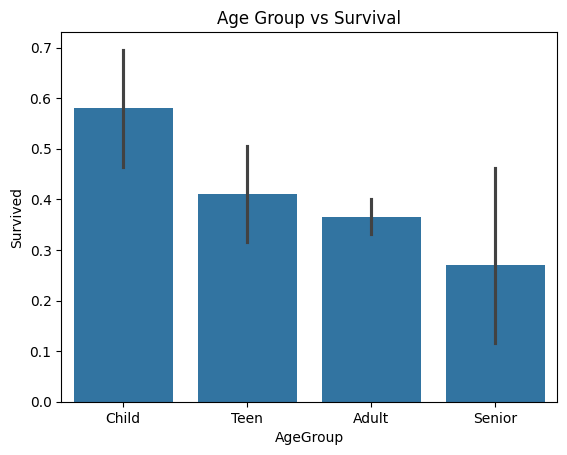

In [50]:
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 12, 19, 59, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

print(data.groupby('AgeGroup')['Survived'].mean())

sns.barplot(x='AgeGroup', y='Survived', data=data)
plt.title('Age Group vs Survival')
plt.show()

## FareGroup

FareGroup
Low         0.071429
Medium      0.266504
High        0.439655
VeryHigh    0.581081
Name: Survived, dtype: float64


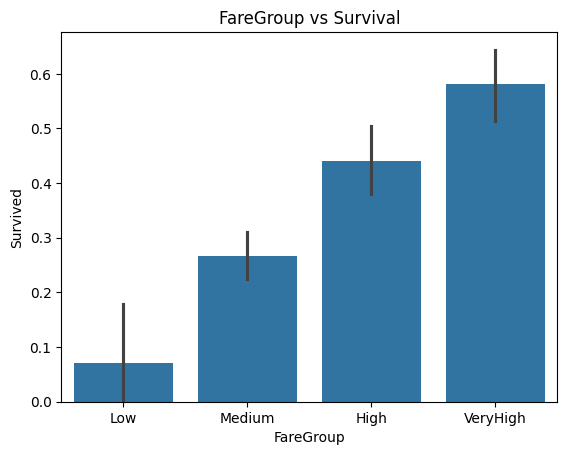

In [51]:
data['FareGroup'] = pd.cut(
    data['Fare'],
    bins=[0, 7, 14, 31, data['Fare'].max()],
    labels=['Low', 'Medium', 'High', 'VeryHigh'],
    include_lowest=True
)

print(data.groupby('FareGroup')['Survived'].mean())

sns.barplot(x='FareGroup', y='Survived', data=data)
plt.title('FareGroup vs Survival')
plt.show()

# Encode Categorical Variables

In [52]:
data['sex_int'] = data['Sex'].map({'male': 1, 'female': 0}).astype(int)
data['Embarked_int'] = data['Embarked'].map({'S': 1, 'C': 2, 'Q': 3}).astype(int)
data['IsAlone_int'] = data['IsAlone'].map({'Yes': 1, 'No': 0}).astype(int)

# Modeling

In [53]:
features = ['Pclass', 'sex_int', 'Fare', 'Embarked_int', 'FamilySize', 'IsAlone_int']
x = data[features]
y = data['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Logistic Regression

In [54]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print('=== Logistic Regression ===')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.8044692737430168

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



## Decision Tree

In [55]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print('=== Decision Tree ===')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print()
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 0.7988826815642458

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Random Forest

In [56]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print('=== Random Forest ===')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8100558659217877

              precision    recall  f1-score   support

           0       0.84      0.83      0.84       105
           1       0.76      0.78      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.81      0.81      0.81       179



## K-Nearest Neighbors

In [57]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

print('=== K-Nearest Neighbors ===')
print('Accuracy:', accuracy_score(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors ===
Accuracy: 0.7877094972067039

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       105
           1       0.76      0.70      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



# Model Comparison

In [58]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.804469
1        Decision Tree  0.798883
2        Random Forest  0.810056
3                  KNN  0.787709
